# TinyML - Liquid Neural Networks (LNN / LTC)

**Author:** Thommas Kevin Sales Flores  
**Institution:** Federal University of Rio Grande do Norte  
**Email:** thommas.flores@ufrn.br

---
This notebook demonstrates how to build, train, and export **Liquid Time-Constant (LTC) Neural Networks** to embedded hardware (Arduino / ESP32).  
All recurrent layers use the LTC cell, which integrates a continuous-time ODE with an **input-dependent time constant** τ(x, h).

### Supported building blocks

| Component | Options |
|-----------|--------|
| **Recurrent cell** | `LTC` (Liquid Time-Constant) |
| **Activation** | `tanh`, `sigmoid`, `relu`, `softmax`, `leaky_relu`, `gelu`, `swish`, `linear` |
| **Loss** | `mse`, `mae`, `rmse`, `bce`, `cce`, `scce`, `huber` |
| **ODE solver** | Fixed-step Euler (`ode_unfolds` micro-steps per input step) |


## Environment Setup

Uncomment and run the cell below the first time to install dependencies.


In [1]:
#!pip install torch numpy matplotlib scikit-learn

## 1. Setup and Imports


In [2]:
import sys, os
sys.path.append('35_LNN')   # adjust if running from a different directory

import torch
import torch.optim as optim
import numpy as np
from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split

from model import LNNModel
from layers import get_activation
from losses import compute_loss, LOSS_NAMES
from utils  import (
    export_to_json,
    train_model,
    plot_training_history,
    plot_regression_uncertainty,
    plot_decision_boundary,
    plot_sequence_prediction,
    plot_time_constants,
)
from cpp_generator import generate_ino

print('Available loss functions:', LOSS_NAMES)

os.makedirs('json_model',   exist_ok=True)
os.makedirs('arduino_code', exist_ok=True)

Available loss functions: ['mse', 'mae', 'rmse', 'bce', 'cce', 'scce', 'huber']


---
## 2. Regression Example: 1D Sine with a Gap

We train a Liquid Neural Network to predict `y = sin(x)` with training data only in the intervals  
`[-4, -1.5]` and `[1.5, 4]`. The model is fed a **sequence of length 1** at each call.

The LNN's adaptive time constant allows it to adjust its sensitivity based on the input magnitude,
producing smoother uncertainty estimates in the gap region compared to a vanilla RNN.


=== Regression — Sine with Gap (LNN/LTC, MSE loss) ===
  Epoch     1/1000  |  MSE = 0.439684
  Epoch   200/1000  |  MSE = 0.001995
  Epoch   400/1000  |  MSE = 0.001974
  Epoch   600/1000  |  MSE = 0.002296
  Epoch   800/1000  |  MSE = 0.001957
  Epoch  1000/1000  |  MSE = 0.002051


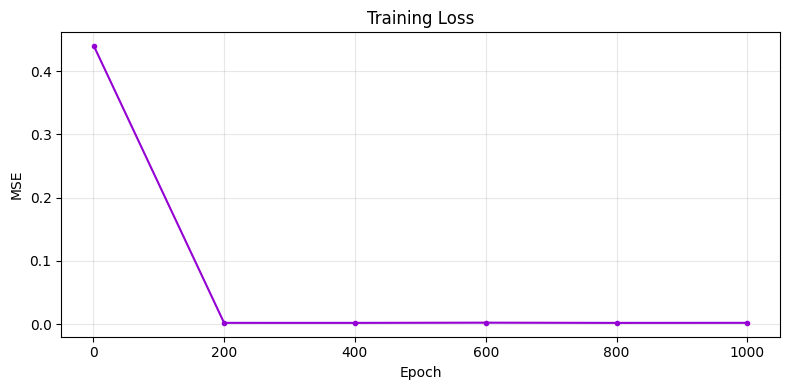

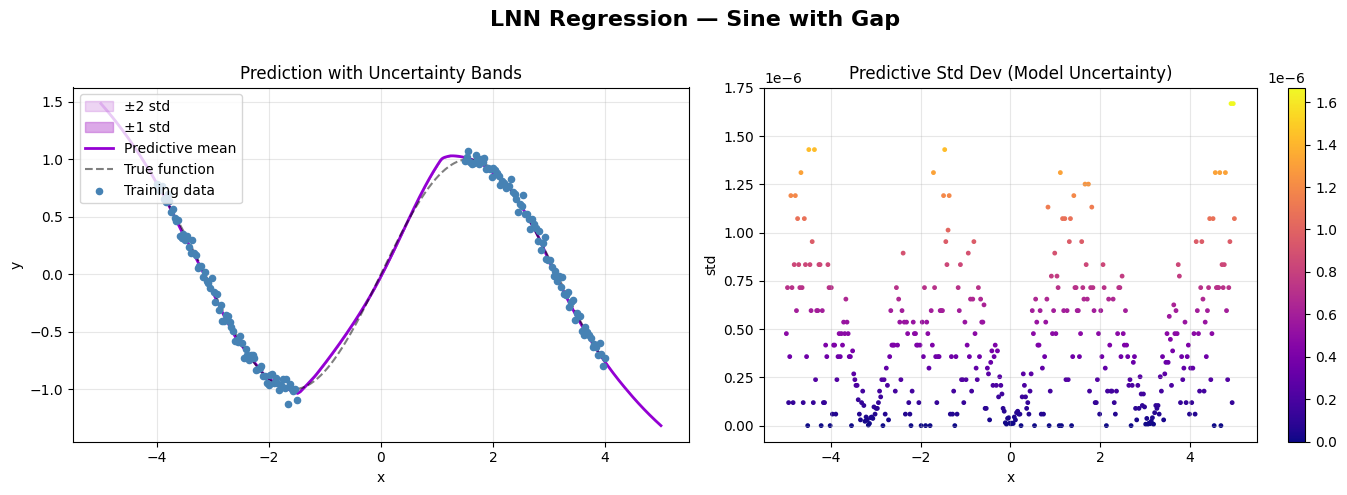

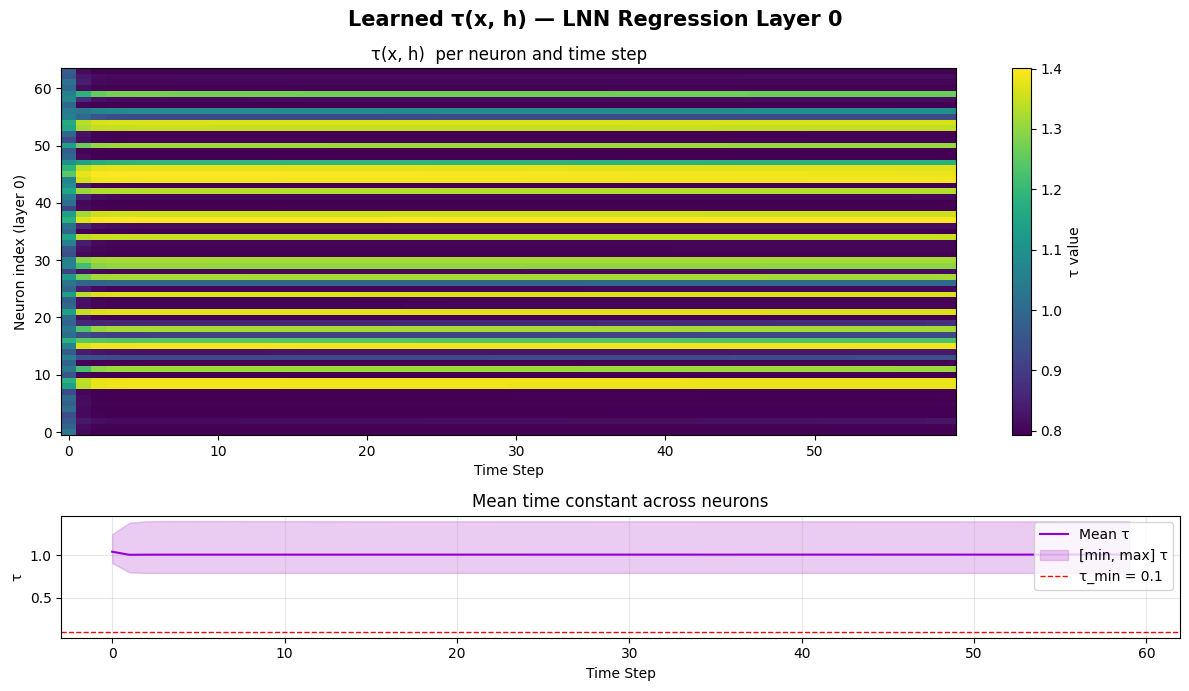

Model exported → json_model/regression_model.json
Generated in : arduino_code/regression_ino  (board: esp32)
Verification  seq_len=4, input_size=1
Expected output (Python) : [1.2784051895141602]


In [3]:
def train_regression():
    print('=== Regression — Sine with Gap (LNN/LTC, MSE loss) ===')
    torch.manual_seed(42)
    np.random.seed(42)

    # ---- Data ----
    x_left  = np.linspace(-4.0, -1.5, 80).astype(np.float32)
    x_right = np.linspace( 1.5,  4.0, 80).astype(np.float32)
    x_train = np.concatenate([x_left, x_right])
    y_train = np.sin(x_train) + 0.05 * np.random.randn(len(x_train)).astype(np.float32)

    x_test = np.linspace(-4.0, 4.0, 400).astype(np.float32)
    y_test = np.sin(x_test)

    # Wrap into (batch, seq_len=1, input_size=1) tensors
    X_t = torch.FloatTensor(x_train).view(-1, 1, 1)
    y_t = torch.FloatTensor(y_train)

    X_te = torch.FloatTensor(x_test).view(-1, 1)
    y_te = torch.FloatTensor(y_test)

    # ---- Architecture ----
    model = LNNModel(
        recurrent_layers=[
            {
                'input_size':  1,
                'hidden_size': 64,
                'activation':  'tanh',
                'ode_unfolds': 6,
                'dt':          1.0,
                'tau_min':     0.1,
            },
        ],
        dense_layers=[
            {'out_features': 32, 'activation': 'relu'},
            {'out_features': 1,  'activation': 'linear'},
        ],
    )

    optimizer = optim.Adam(model.parameters(), lr=0.005)

    # ---- Train ----
    history = train_model(
        model, X_t, y_t, optimizer,
        loss_name='mse', epochs=1000, print_every=200,
    )
    plot_training_history(history, loss_name='mse')

    # ---- Visualize prediction + uncertainty ----
    plot_regression_uncertainty(
        model,
        X_train=torch.FloatTensor(x_train).view(-1, 1),
        y_train=torch.FloatTensor(y_train),
        X_test=X_te,
        y_test=y_te,
        title='LNN Regression — Sine with Gap',
        n_samples=100, seq_len=1,
    )

    # ---- Visualize time constants ----
    sample = torch.FloatTensor(x_test[:60]).view(1, 60, 1)
    plot_time_constants(
        model, sample,
        layer_idx=0,
        title='Learned τ(x, h) — LNN Regression Layer 0',
    )

    # ---- Export ----
    export_to_json(model, 'json_model/regression_model.json')
    generate_ino(
        'json_model/regression_model.json',
        'arduino_code/regression_ino',
        board='esp32', task='regression',
    )
    return model


model_reg = train_regression()

---
## 3. Binary Classification Example: Two Moons

The classic `make_moons` dataset with a 2-D input wrapped as a sequence of length 1.  
Binary Cross-Entropy loss with logit output.


=== Binary Classification — Two Moons (LNN/LTC, BCE loss) ===
X_train[0]: [0.4418464 0.7568234]   y_train[0]: 0
  Epoch     1/1000  |  BCE = 0.691712
  Epoch   200/1000  |  BCE = 0.093585
  Epoch   400/1000  |  BCE = 0.073180
  Epoch   600/1000  |  BCE = 0.057686
  Epoch   800/1000  |  BCE = 0.031058
  Epoch  1000/1000  |  BCE = 0.017613


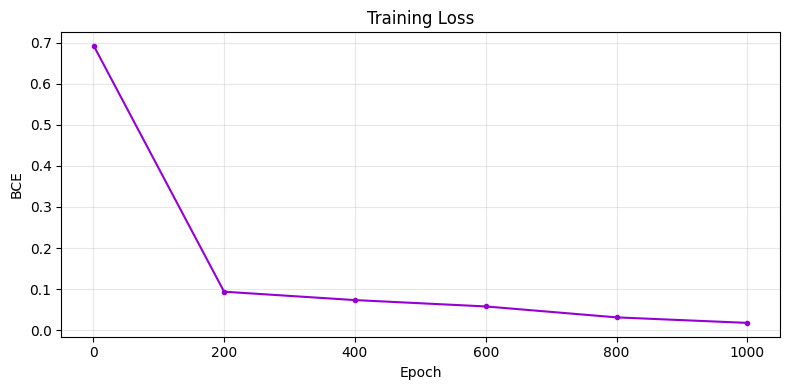

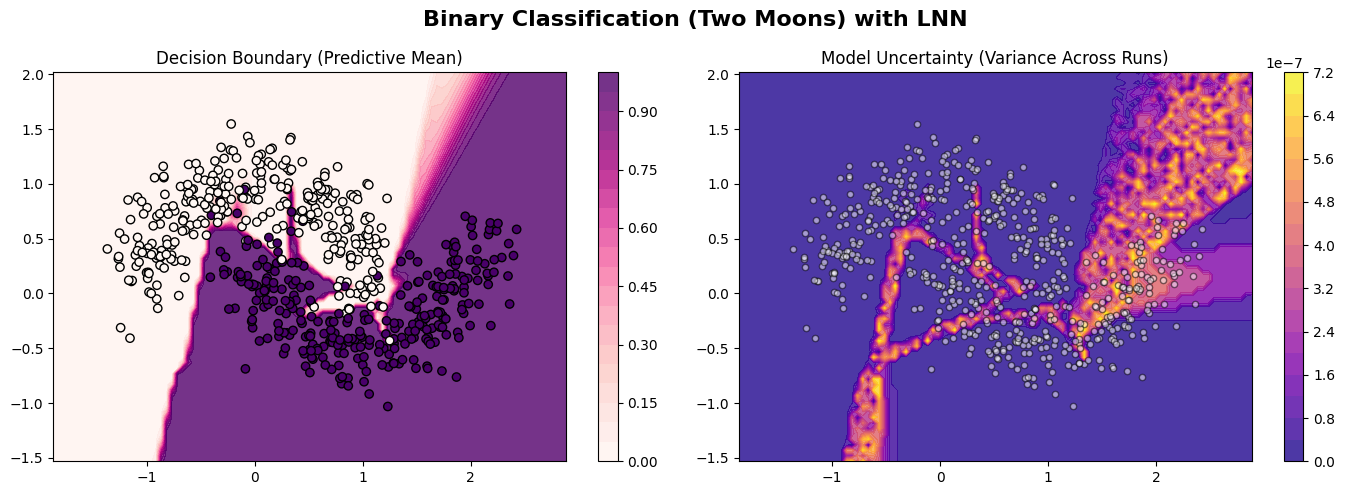

Model exported → json_model/binary_model.json
Generated in : arduino_code/binary_ino  (board: esp32)
Verification  seq_len=4, input_size=2
Expected output (Python) : [19.283382415771484]


In [4]:
def train_binary():
    print('=== Binary Classification — Two Moons (LNN/LTC, BCE loss) ===')
    torch.manual_seed(42)

    # ---- Data ----
    X, y = make_moons(n_samples=600, noise=0.2, random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

    print('X_train[0]:', X_tr[0], '  y_train[0]:', y_tr[0])

    X_t = torch.FloatTensor(X_tr.astype(np.float32)).unsqueeze(1)  # (N, 1, 2)
    y_t = torch.FloatTensor(y_tr.astype(np.float32))               # (N,)

    # ---- Architecture ----
    model = LNNModel(
        recurrent_layers=[
            {
                'input_size':  2,
                'hidden_size': 32,
                'activation':  'tanh',
                'ode_unfolds': 6,
                'dt':          1.0,
                'tau_min':     0.1,
            },
        ],
        dense_layers=[
            {'out_features': 16, 'activation': 'relu'},
            {'out_features': 1,  'activation': 'linear'},  # logit output
        ],
    )

    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # ---- Train ----
    history = train_model(
        model, X_t, y_t, optimizer,
        loss_name='bce', epochs=1000, print_every=200,
    )
    plot_training_history(history, loss_name='bce')

    # ---- Visualize ----
    plot_decision_boundary(
        model, X, y,
        title='Binary Classification (Two Moons) with LNN',
        task='binary', seq_len=1,
    )

    # ---- Export ----
    export_to_json(model, 'json_model/binary_model.json')
    generate_ino(
        'json_model/binary_model.json',
        'arduino_code/binary_ino',
        board='esp32', task='binary',
    )
    return model


model_bin = train_binary()

---
## 4. Multiclass Classification Example: Three Blobs

Three Gaussian clusters, Sparse Categorical Cross-Entropy loss.


=== Multiclass Classification — Blobs (LNN/LTC, SCCE loss) ===
X_train[0]: [-2.62485019  9.52601409]   y_train[0]: 0
  Epoch     1/1000  |  SCCE = 1.103045
  Epoch   200/1000  |  SCCE = 0.000026
  Epoch   400/1000  |  SCCE = 0.000016
  Epoch   600/1000  |  SCCE = 0.000011
  Epoch   800/1000  |  SCCE = 0.000008
  Epoch  1000/1000  |  SCCE = 0.000006


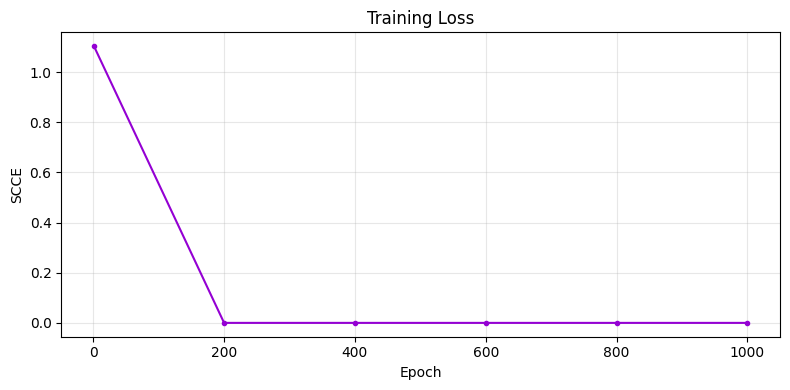

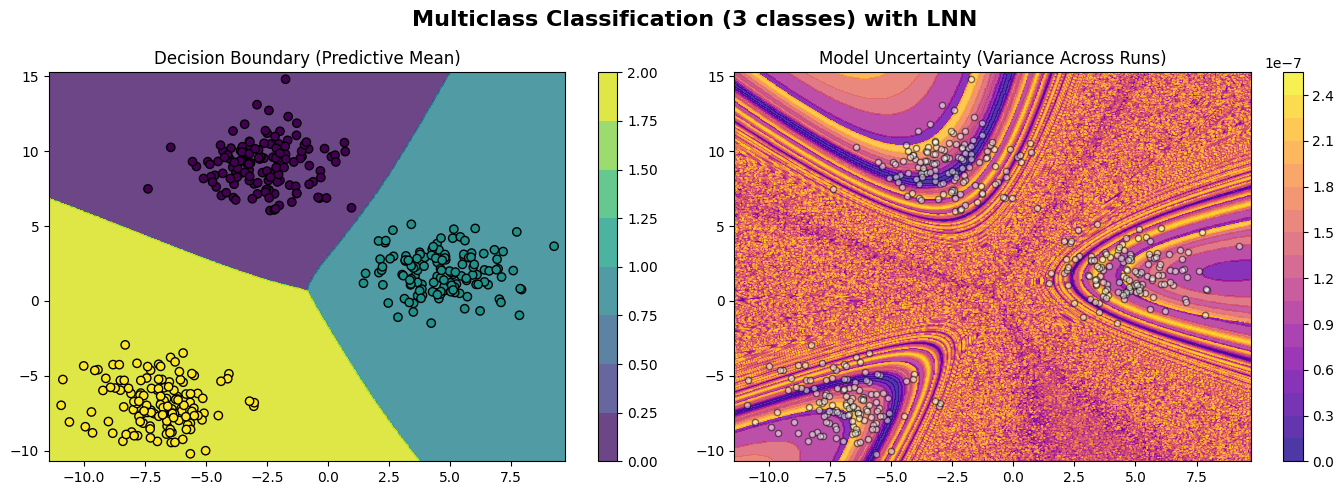

Model exported → json_model/multiclass_model.json
Generated in : arduino_code/multiclass_ino  (board: esp32)
Verification  seq_len=4, input_size=2
Expected output (Python) : [-9.776007652282715, 11.725044250488281, -6.210236072540283]


In [5]:
def train_multiclass():
    print('=== Multiclass Classification — Blobs (LNN/LTC, SCCE loss) ===')
    torch.manual_seed(42)

    # ---- Data ----
    X, y = make_blobs(n_samples=400, centers=3, cluster_std=1.5, random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

    print('X_train[0]:', X_tr[0], '  y_train[0]:', y_tr[0])

    X_t = torch.FloatTensor(X_tr.astype(np.float32)).unsqueeze(1)  # (N, 1, 2)
    y_t = torch.LongTensor(y_tr)                                   # integer labels

    # ---- Architecture ----
    model = LNNModel(
        recurrent_layers=[
            {
                'input_size':  2,
                'hidden_size': 32,
                'activation':  'tanh',
                'ode_unfolds': 6,
                'dt':          1.0,
                'tau_min':     0.1,
            },
        ],
        dense_layers=[
            {'out_features': 16, 'activation': 'relu'},
            {'out_features': 3,  'activation': 'linear'},  # 3 classes
        ],
    )

    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # ---- Train ----
    history = train_model(
        model, X_t, y_t, optimizer,
        loss_name='scce', epochs=1000, print_every=200,
    )
    plot_training_history(history, loss_name='scce')

    # ---- Visualize ----
    plot_decision_boundary(
        model, X, y,
        title='Multiclass Classification (3 classes) with LNN',
        task='multiclass', seq_len=1,
    )

    # ---- Export ----
    export_to_json(model, 'json_model/multiclass_model.json')
    generate_ino(
        'json_model/multiclass_model.json',
        'arduino_code/multiclass_ino',
        board='esp32', task='multiclass',
    )
    return model


model_multi = train_multiclass()

---
## 5. Sequence-to-Sequence Example: Noisy Sine Prediction

A true sequence task: the model receives a window of `T = 30` steps and must predict the next step at
every position.  Uses `forward_sequence()` to obtain per-step outputs.  
Two stacked LTC layers demonstrate depth in the liquid state — each layer has its own
adaptive time constant, allowing the stack to operate at multiple temporal scales simultaneously.


=== Seq-to-Seq Sine Prediction (Stacked LNN/LTC, MSE loss) ===
X shape: torch.Size([497, 30, 1])   Y shape: torch.Size([497, 30])
  Epoch    1/500  |  MSE = 0.560504
  Epoch  100/500  |  MSE = 0.017613
  Epoch  200/500  |  MSE = 0.014907
  Epoch  300/500  |  MSE = 0.013709
  Epoch  400/500  |  MSE = 0.013018
  Epoch  500/500  |  MSE = 0.014013


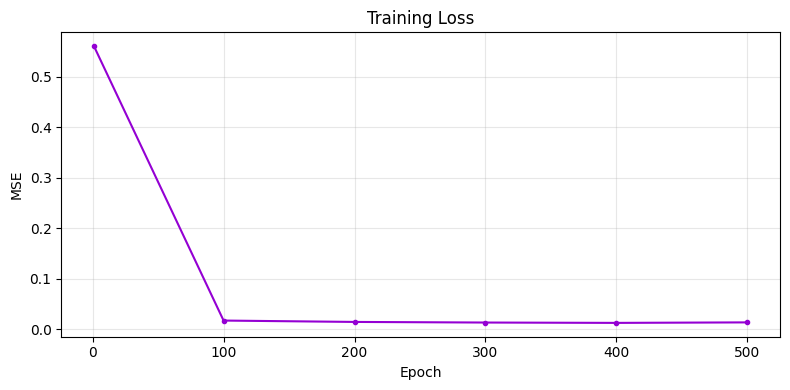

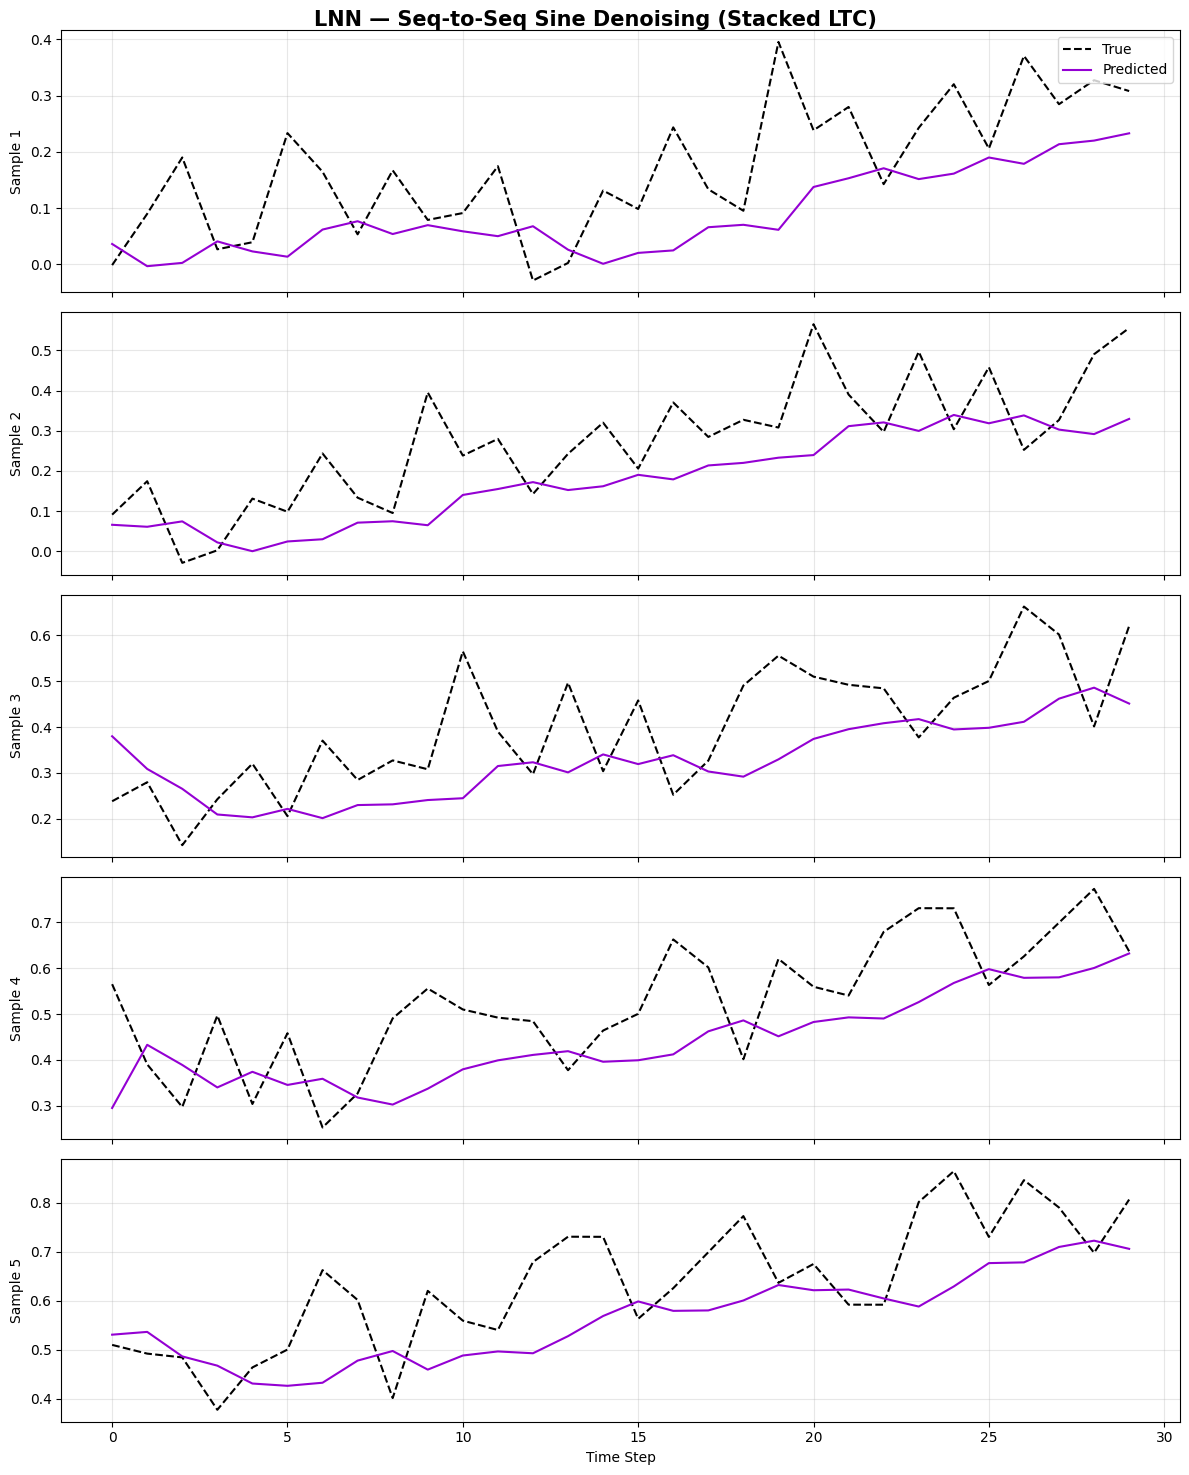

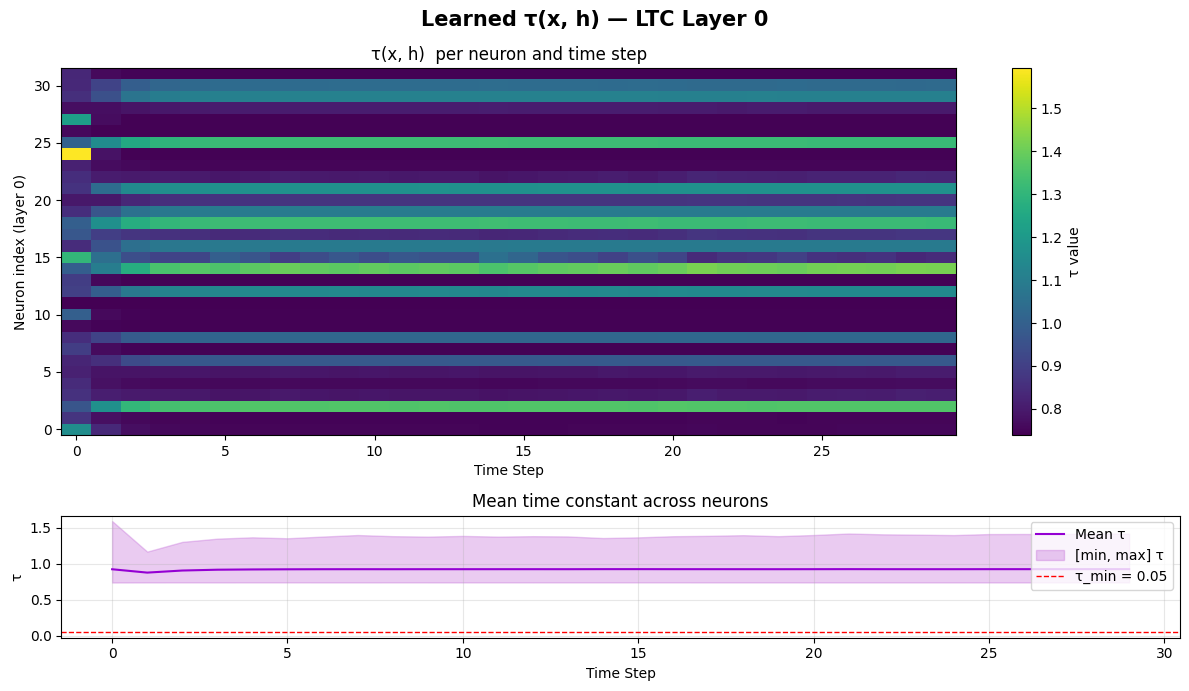

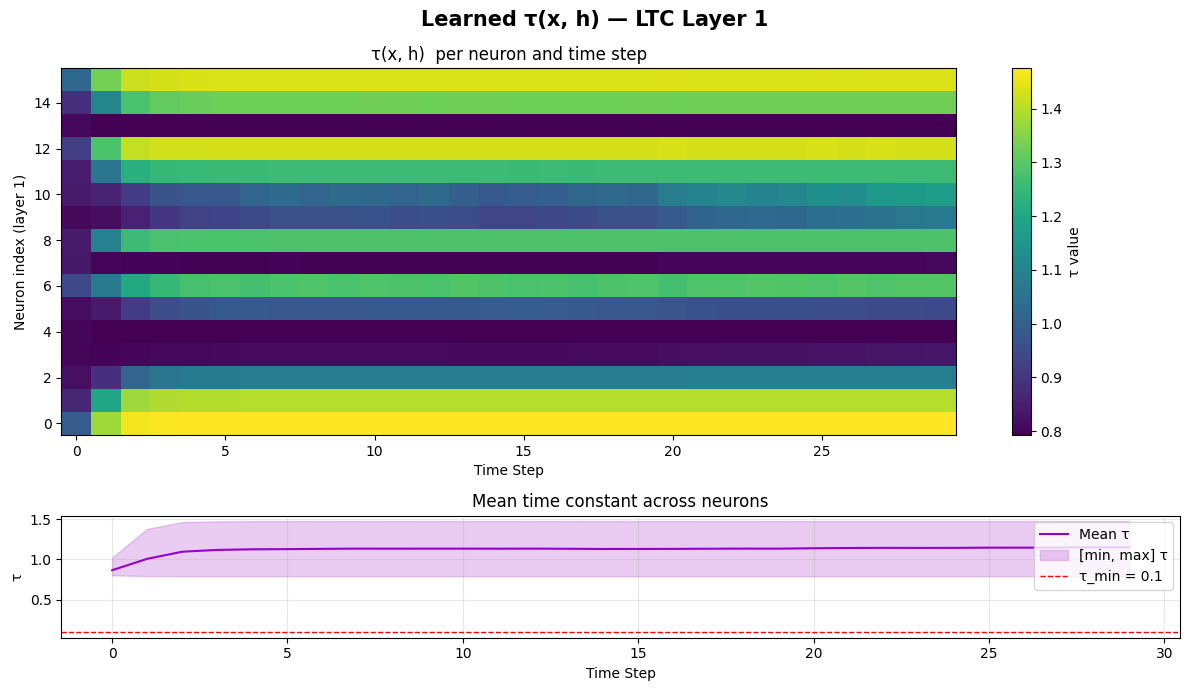

Model exported → json_model/seq2seq_model.json
Generated in : arduino_code/seq2seq_ino  (board: esp32)
Verification  seq_len=4, input_size=1
Expected output (Python) : [1.2672683000564575]


: 

In [ ]:
def train_seq2seq():
    print('=== Seq-to-Seq Sine Prediction (Stacked LNN/LTC, MSE loss) ===')
    torch.manual_seed(42)
    np.random.seed(42)

    T = 30

    # ---- Data: overlapping windows of a noisy sine wave ----
    t_full = np.linspace(0, 20 * np.pi, 5000).astype(np.float32)
    signal = np.sin(t_full) + 0.1 * np.random.randn(len(t_full)).astype(np.float32)

    X_list, Y_list = [], []
    for start in range(0, len(signal) - T - 1, T // 3):
        window = signal[start : start + T]
        target = signal[start + 1 : start + T + 1]
        X_list.append(window)
        Y_list.append(target)

    X = torch.FloatTensor(np.array(X_list)).unsqueeze(-1)   # (N, T, 1)
    Y = torch.FloatTensor(np.array(Y_list))                  # (N, T)
    print(f'X shape: {X.shape}   Y shape: {Y.shape}')

    # ---- Architecture: two stacked LTC layers ----
    model = LNNModel(
        recurrent_layers=[
            {
                'input_size':  1,
                'hidden_size': 32,
                'activation':  'tanh',
                'ode_unfolds': 6,
                'dt':          1.0,
                'tau_min':     0.05,
            },
            {
                'input_size':  32,
                'hidden_size': 16,
                'activation':  'tanh',
                'ode_unfolds': 4,
                'dt':          1.0,
                'tau_min':     0.1,
            },
        ],
        dense_layers=[
            {'out_features': 1, 'activation': 'linear'},
        ],
    )

    optimizer = optim.Adam(model.parameters(), lr=0.005)

    # ---- Train (sequence loss over all time steps) ----
    epochs = 500
    print_every = 100
    history = []
    model.train()

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        pred = model.forward_sequence(X).squeeze(-1)   # (N, T)
        loss = torch.nn.functional.mse_loss(pred, Y)
        loss.backward()
        optimizer.step()

        if epoch % print_every == 0 or epoch == 1:
            print(f'  Epoch {epoch:>4}/{epochs}  |  MSE = {loss.item():.6f}')
            history.append((epoch, loss.item()))

    plot_training_history(history, loss_name='mse')

    # ---- Visualize predictions on 5 samples ----
    plot_sequence_prediction(
        model, X[:5], Y[:5],
        title='LNN — Seq-to-Seq Sine Denoising (Stacked LTC)',
        n_display=5,
    )

    # ---- Visualize time constants in both LTC layers ----
    sample_seq = X[:1]   # single sequence
    for layer_idx in range(2):
        plot_time_constants(
            model, sample_seq,
            layer_idx=layer_idx,
            title=f'Learned τ(x, h) — LTC Layer {layer_idx}',
        )

    # ---- Export (last-step → regression for Arduino) ----
    export_to_json(model, 'json_model/seq2seq_model.json')
    generate_ino(
        'json_model/seq2seq_model.json',
        'arduino_code/seq2seq_ino',
        board='esp32', task='regression',
    )
    return model


model_s2s = train_seq2seq()

---
## 6. Quick Reference — Architecture & Hyperparameters

### LTC cell hyperparameters (pass in `recurrent_layers` dict)

| Key | Type | Default | Description |
|-----|------|---------|-------------|
| `input_size` | int | *required* | Dimensionality of the input |
| `hidden_size` | int | *required* | Dimensionality of the liquid state |
| `activation` | str | `'tanh'` | Backbone nonlinearity |
| `ode_unfolds` | int | `6` | Euler micro-steps per input time step |
| `dt` | float | `1.0` | Nominal continuous-time step |
| `tau_min` | float | `0.1` | Minimum time-constant floor |
| `bias` | bool | `True` | Whether to include bias terms |

**Tuning tips:**
- Increase `ode_unfolds` (e.g. 10–12) for better ODE accuracy at the cost of more computation.
- Decrease `tau_min` (e.g. 0.01) to allow faster-adapting neurons.
- Increase `dt` to make the network sensitive to longer-range temporal patterns.

### Activation functions

| Name | Key string |
|------|------------|
| Tanh | `'tanh'` |
| Sigmoid | `'sigmoid'` |
| ReLU | `'relu'` |
| Softmax | `'softmax'` |
| Leaky ReLU | `'leaky_relu'` |
| GELU | `'gelu'` |
| Swish | `'swish'` |
| Linear (identity) | `'linear'` |

### Loss functions

| Name | Key string | Use case |
|------|------------|----------|
| Mean Squared Error | `'mse'` | Regression |
| Mean Absolute Error | `'mae'` | Regression (robust) |
| Root MSE | `'rmse'` | Regression |
| Binary Cross-Entropy | `'bce'` | Binary classification |
| Categorical Cross-Entropy | `'cce'` | Multiclass (one-hot targets) |
| Sparse CCE | `'scce'` | Multiclass (integer targets) |
| Huber | `'huber'` | Regression (robust to outliers) |

### Example: two-layer LNN with GELU dense activation and Huber loss

```python
model = LNNModel(
    recurrent_layers=[
        {
            'input_size':  4,
            'hidden_size': 128,
            'activation':  'tanh',
            'ode_unfolds': 8,
            'dt':          1.0,
            'tau_min':     0.05,
        },
    ],
    dense_layers=[
        {'out_features': 64, 'activation': 'gelu'},
        {'out_features': 1,  'activation': 'linear'},
    ],
)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
history = train_model(model, X_train, y_train, optimizer,
                      loss_name='huber', epochs=500, delta=1.0)
```
